# Event Hub Query Notebook

This notebook processes the Azure Event Hubs PDF documentation and attempts to answer questions about reading messages from Event Hub using the Self-RAG approach.

In [1]:
import os
import sys
from dotenv import load_dotenv

# Add the project directory to the path
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))

from app.utils.document_processor import process_document, split_text, extract_text
from app.utils.embedding_utils import create_vector_store
from app.models.self_rag import SelfRAG

## 1. Load Environment Variables

In [2]:
# Load environment variables
load_dotenv()

# Set the PDF path and question
pdf_path = "resources/event-hub.pdf"
question = "how can I read messages from event hub?"

print(f"Processing document: {pdf_path}")
print(f"Question: {question}")
print("-" * 50)

Processing document: resources/event-hub.pdf
Question: how can I read messages from event hub?
--------------------------------------------------


## 2. Extract Text from PDF

In [3]:
try:
    # Extract text from PDF
    print("Extracting text from PDF...")
    text = extract_text(pdf_path)
    
    # Print a sample of the extracted text
    print("\nSample of extracted text:")
    print(text[:500] + "...")
except Exception as e:
    print(f"Error extracting text from PDF: {str(e)}")
    import traceback
    traceback.print_exc()

Extracting text from PDF...

Sample of extracted text:
Azure Event Hubs: A Comprehensive Overview 
Introduction 
Azure Event Hubs is a cloud-based event streaming platform and event ingestion service 
designed to handle large-scale data streams in real-time. It enables businesses to capture, 
process, and analyze massive amounts of data from various sources. This guide provides 
an in-depth look at Azure Event Hubs, including its architecture, key features, use cases, 
pricing model, and best practices. 
What is Azure Event Hubs? 
Azure Event Hubs i...


## 3. Split Text into Chunks

In [4]:
try:
    # Split text into smaller chunks for better processing
    print("Splitting text into chunks...")
    chunks = split_text(text, chunk_size=500, chunk_overlap=50)
    
    print(f"Document processed successfully. Found {len(chunks)} chunks.")
    
    # Print a sample chunk
    if chunks:
        print("\nSample chunk:")
        print(chunks[0])
except Exception as e:
    print(f"Error splitting text: {str(e)}")
    import traceback
    traceback.print_exc()

Splitting text into chunks...
Document processed successfully. Found 3 chunks.

Sample chunk:
Azure Event Hubs: A Comprehensive Overview 
Introduction 
Azure Event Hubs is a cloud-based event streaming platform and event ingestion service 
designed to handle large-scale data streams in real-time. It enables businesses to capture, 
process, and analyze massive amounts of data from various sources. This guide provides 
an in-depth look at Azure Event Hubs, including its architecture, key features, use cases, 
pricing model, and best practices. 
What is Azure Event Hubs? 
Azure Event Hubs is a managed event ingestion service that enables applications to 
process millions of events per second. It is highly scalable and designed to integrate 
seamlessly with Azure services and third-party platforms. 
Key Features 
 Real-time Data Streaming: Event Hubs supports low-latency, high-throughput data 
ingestion and streaming. 
 Multiple Protocols Support: It supports AMQP , Kafka, and HTTP-based

## 4. Create Vector Store

Note: This step requires Ollama to be running for the embedding model.

In [5]:
try:
    # Create vector store from document chunks
    metadatas = [{"chunk_id": i, "source": os.path.basename(pdf_path)} for i in range(len(chunks))]
    
    print("Creating vector store...")
    vector_store = create_vector_store(
        texts=chunks,
        metadatas=metadatas
    )
    
    print("Vector store created successfully.")
except Exception as e:
    print(f"Error creating vector store: {str(e)}")
    import traceback
    traceback.print_exc()

Creating vector store...


C:\Users\MSI-1\Downloads\projects\selfRag\app\utils\embedding_utils.py:9: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaEmbeddings``.
  return OllamaEmbeddings(model="nomic-embed-text:latest")


Vector store created successfully.


## 5. Initialize Self-RAG

Note: This step requires Ollama to be running for the LLM model.

In [6]:
try:
    # Initialize Self-RAG
    self_rag = SelfRAG(vector_store=vector_store)
    
    print("Self-RAG initialized.")
except Exception as e:
    print(f"Error initializing Self-RAG: {str(e)}")
    import traceback
    traceback.print_exc()

Self-RAG initialized.


C:\Users\MSI-1\Downloads\projects\selfRag\app\models\self_rag.py:48: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaLLM``.
  self.llm = Ollama(model=model_name, temperature=0)


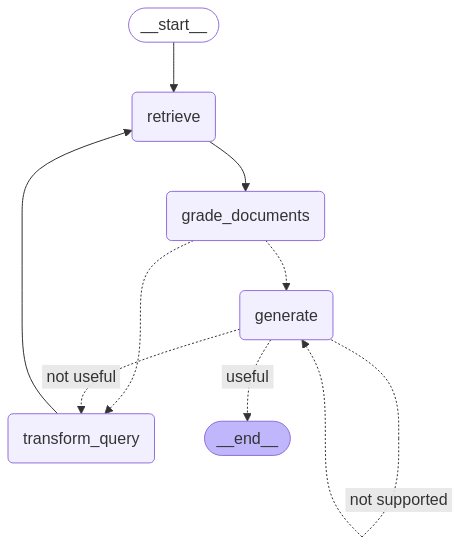

In [7]:
from IPython.display import Image, display

try:
    display(Image(self_rag.get_workflow_graph().get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

## 6. Process Question and Get Answer

In [8]:
try:
    # Process question and get answer
    print("Processing question...")
    result = self_rag.process_document_and_answer(question)
    
    print("\nFinal Answer:")
    print(result.get("generation", "No answer generated"))
except Exception as e:
    print(f"Error processing question: {str(e)}")
    import traceback
    traceback.print_exc()

Processing question...



KeyboardInterrupt



## 7. Display Relevant Sources

In [ ]:
try:
    print("\nRelevant Sources:")
    if "documents" in result:
        relevant_count = 0
        for i, doc in enumerate(result["documents"]):
            if doc.get("relevant", False):
                relevant_count += 1
                print(f"\nSource {relevant_count}:")
                # Print a shorter snippet to avoid overwhelming output
                content = doc["page_content"]
                if len(content) > 300:
                    content = content[:300] + "..."
                print(content)
        
        if relevant_count == 0:
            print("No relevant sources found.")
except Exception as e:
    print(f"Error displaying sources: {str(e)}")
    import traceback
    traceback.print_exc()